# Host Anomaly Detection (ADFA-LD): CNN + DBSCAN

Consolidates the team scripts into one notebook, using the same methods that produced the report results:
- **CNN** = `ThomTest.py` + `ConvolNN.py`: train on every normal + attack log, 100 epochs per file, then predict per log.
- **DBSCAN** = `KayTest.py`: attack traces only, 340-dim syscall frequency vectors, `eps=0.15`, `min_samples=5`, no scaling.

## 1. Setup

In [ ]:
import os
import sys


# Locate root directory
root = Path.cwd()
while not (root / "src" / "NeuralNet").is_dir():
    if root.parent == root:
        raise FileNotFoundError("Could not find repo root containing src/NeuralNet.")
    root = root.parent

for p in (root / "src", root / "src" / "NeuralNet"):
    if str(p) not in sys.path:
        sys.path.append(str(p))
ADFA_DIR = root / "dat" / "HostLogs" / "ADFA-LD_Logs"

import NeuralNet.HostLogPreprocessor as HLpP
import NeuralNet.NetLogPreprocessor as NLpP
from NeuralNet.ConvolNN import ConvolNN as CNN
from NeuralNet.NNUtils import PreprocessingState as PpS, PreprocessingData as PpD, LogFormat, Model, NNConfig, AnomalyType

from pathlib import Path
import random
attackDataDir = ADFA_DIR / "Attack_Data_Master"
trainingDataDir = ADFA_DIR / "Training_Data_Master"
validationDataDir = ADFA_DIR / "Validation_Data_Master"



cnnCfg = NNConfig(model=Model.CONVOLUTIONAL)
stateCfg = PpS (model=Model.CONVOLUTIONAL,
                logFormat=LogFormat.ADFALD, 
                isTraining=True, doDebug=False)

preprocessor = HLpP.HostLogPreprocessor(stateCfg)
trainingStateDat:tuple[PpS, PpD] = preprocessor.GetStateData()
model = CNN(config=cnnCfg, state=trainingStateDat[0], data=trainingStateDat[1])

def AddFilesToTrainingData(dir:Path, trainingData:list[Path]) -> list[Path]:
    newData = trainingData
    for f in dir.rglob("*.txt"):
        if f.is_file(): newData.append(f)

    return newData

def TrainModel(metaEpoch:int, epochs: int, files:list[Path], doShuffle:bool = True):
    data = files
    model.train()            #Tell the pytorch NN it's in training mode
    model.lossData.clear()
    
    for i in range(metaEpoch):        
        trainingData = data
        if doShuffle: random.shuffle(trainingData)
    
        while trainingData:
            file = trainingData.pop()        
            stateCfg.logName=f"{file.name}"
            stateCfg.logPath=file
            stateCfg.isAnomalous = stateCfg.DetIsAnomolous()
            if trainingDataDir.as_posix() in Path(file).as_posix():
                stateCfg.anomalyType = AnomalyType.NORMAL
            else: stateCfg.anomalyType = stateCfg.DetAnomalyType()

            preprocessor.Load(stateCfg)
            trainingStateDat = preprocessor.GetStateData()
            model.state = trainingStateDat[0]
            model.data = trainingStateDat[1]
            model.Train(epochs) 


def PredictModel(logDir:Path):
    for file in logDir.rglob("*.txt"):
        if file.is_file():        
            stateCfg.logName=f"{file.name}"
            stateCfg.logPath=file

            preprocessor.Load(stateCfg)
            trainingStateDat = preprocessor.GetStateData()
            model.state = trainingStateDat[0]
            model.data = trainingStateDat[1]

            print("\n---------- RESULTS ----------")
            print(f"\tLog: {stateCfg.logName}, {stateCfg.logPath}")
            print(f"\tResult: {model.Predict()}\n\n")


normalTrainingData:list[Path] = []
attackTrainingData:list[Path] = []
allTrainingData:list[Path] = []

AddFilesToTrainingData(trainingDataDir, normalTrainingData)
AddFilesToTrainingData(attackDataDir, attackTrainingData)
AddFilesToTrainingData(trainingDataDir, allTrainingData)
AddFilesToTrainingData(attackDataDir, allTrainingData)


TrainModel(1, 100, allTrainingData, True) 

model.state.isTraining = False
#PredictModel(trainingDataDir)
#PredictModel(attackDataDir)

In [35]:
# 1. Collect all normal and attack log files
normal_files = [f for f in trainingDataDir.rglob("*.txt") if f.is_file()]
attack_files = [f for f in attackDataDir.rglob("*.txt") if f.is_file()]

# 2. Get predictions and ground truth
def get_prediction(file):
    stateCfg.logName = file.name
    stateCfg.logPath = file
    preprocessor.Load(stateCfg)
    state, data = preprocessor.GetStateData()
    model.state, model.data = state, data
    # Predict returns an AnomalyType enum (e.g. AnomalyType.NORMAL, AnomalyType.HYDRAFTP)
    return model.Predict()

def get_actual_attack_type(file):
    stateCfg.logPath = file
    return stateCfg.DetAnomalyType()

print("Evaluating normal files...")
normal_preds = [get_prediction(f) for f in normal_files]

print("Evaluating attack files...")
attack_preds = [get_prediction(f) for f in attack_files]
attack_actuals = [get_actual_attack_type(f) for f in attack_files]

# 3. Calculate Binary TP, FP, FN, TN
binary_tp = sum(p != AnomalyType.NORMAL for p in attack_preds)
binary_fn = sum(p == AnomalyType.NORMAL for p in attack_preds)
binary_fp = sum(p != AnomalyType.NORMAL for p in normal_preds)
binary_tn = sum(p == AnomalyType.NORMAL for p in normal_preds)

# 4. Calculate Multiclass/Family TP and FP
class_tp = sum(act == pred for act, pred in zip(attack_actuals, attack_preds))
class_fp = sum(act != pred for act, pred in zip(attack_actuals, attack_preds))

# 5. Calculate Metrics
precision = binary_tp / (binary_tp + binary_fp) if (binary_tp + binary_fp) > 0 else 0
recall = class_tp / (class_tp + class_fp) if (class_tp + class_fp) > 0 else 0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# 6. Print the exact report table
print("\n" + "="*50)
print(f"Binary TP: {binary_tp}")
print(f"Binary FP: {binary_fp}")
print(f"Binary FN: {binary_fn}")
print(f"Binary TN: {binary_tn}")
print(f"Class TP:  {class_tp}")
print(f"Class FP:  {class_fp}")
print("="*50)
print(f"P  = {binary_tp} / ({binary_tp} + {binary_fp}) = {precision:.4f} ({precision*100:.2f}%)")
print(f"R  = {class_tp} / ({class_tp} + {class_fp}) = {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 = 2PR / (P + R) = {f1:.4f} ({f1*100:.2f}%)")
print("="*50)

Evaluating normal files...
Prediction count: tensor([   0,    0,    0,    0,    0,    0,    0, 1078])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 128])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 107])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 509])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 788])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 193])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 359])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 781])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 721])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 792])
Final Prediction: 7
Prediction count: tensor([  0,   0,   0,   0,   0,   0,   0, 160])
Final Prediction: 7
Predicti

## 5. DBSCAN on attack traces

Each attack trace becomes a 340-dim vector of relative syscall frequencies (`count(syscall_i) / N`). If Kay's `X_adfa.npy` / `y_adfa.npy` exist they are loaded (so results match his run); otherwise the vectors are built from the attack logs.

In [21]:
N_DIMS = 340

def frequency_vector(file):
    ids = np.array(file.read_text().split(), dtype=np.int64)
    counts = np.bincount(ids[ids < N_DIMS], minlength=N_DIMS)
    return counts / max(len(ids), 1)

kay_x = next((p for p in (Path("X_adfa.npy"), root / "X_adfa.npy") if p.exists()), None)
if kay_x is not None:
    X = np.load(kay_x)
    y = np.load(kay_x.with_name("y_adfa.npy"))
    X_att = X[y == 1]
    print("Loaded", kay_x)
else:
    X_att = np.array([frequency_vector(f) for f in attack_files])
    print("Built frequency vectors from attack logs")
print("Attack traces:", X_att.shape, "(report: 746 x 340)")

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

labels = DBSCAN(eps=0.15, min_samples=5).fit(X_att).labels_
n_clusters = len(set(labels) - {-1})
n_noise = int(np.sum(labels == -1))
print(f"{n_clusters} clusters, {n_noise} noise ({n_noise / len(X_att):.1%})   (report: 19 clusters, 62 noise, 8.3%)")

Built frequency vectors from attack logs
Attack traces: (746, 340) (report: 746 x 340)
19 clusters, 62 noise (8.3%)   (report: 19 clusters, 62 noise, 8.3%)



Cluster 3: 178 traces (23.9%)
  Elevated:   ID 168 (prctl), ID 265 (syscalls), ID 3 (io_submit)
  Suppressed: ID 78 (tee), ID 5 (io_getevents)

Cluster 10: 129 traces (17.3%)
  Elevated:   ID 5 (io_getevents), ID 192 (semctl), ID 6 (setxattr)
  Suppressed: ID 168 (prctl), ID 265 (syscalls)

Cluster 2: 59 traces (7.9%)
  Elevated:   ID 142 (getpriority), ID 3 (io_submit), ID 104 (setitimer)
  Suppressed: ID 168 (prctl), ID 78 (tee)

Cluster 1: 50 traces (6.7%)
  Elevated:   ID 168 (prctl), ID 265 (syscalls), ID 339
  Suppressed: ID 3 (io_submit), ID 78 (tee)

Cluster 5: 46 traces (6.2%)
  Elevated:   ID 174 (getppid), ID 192 (semctl), ID 33 (flock)
  Suppressed: ID 168 (prctl), ID 265 (syscalls)

Cluster 9: 29 traces (3.9%)
  Elevated:   ID 13 (llistxattr), ID 4 (io_cancel), ID 240 (move_pages)
  Suppressed: ID 168 (prctl), ID 3 (io_submit)

Cluster 14: 29 traces (3.9%)
  Elevated:   ID 78 (tee), ID 140 (rt_sigreturn), ID 195 (shmget)
  Suppressed: ID 168 (prctl), ID 265 (syscalls)

Cl

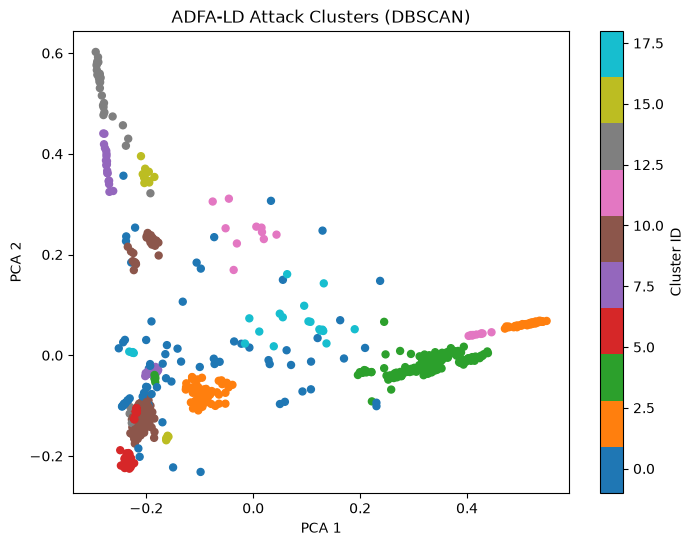

In [22]:
global_mean = X_att.mean(axis=0)

def name(i):
    return f"ID {i} ({syscall_names[i]})" if i in syscall_names else f"ID {i}"

sizes = Counter(int(c) for c in labels if c != -1)
for c, count in sizes.most_common():
    mask = labels == c
    diff = X_att[mask].mean(axis=0) - global_mean
    print(f"\nCluster {c}: {count} traces ({count / len(X_att):.1%})")
    print("  Elevated:   " + ", ".join(name(i) for i in np.argsort(diff)[-3:][::-1]))
    print("  Suppressed: " + ", ".join(name(i) for i in np.argsort(diff)[:2]))
print(f"\nNoise (-1): {n_noise} traces ({n_noise / len(X_att):.1%})")

X_pca = PCA(n_components=2).fit_transform(X_att)
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=25)
plt.title("ADFA-LD Attack Clusters (DBSCAN)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.colorbar(sc, label="Cluster ID")
plt.savefig("attack_clusters.png", dpi=150)
plt.show()